In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Week 5 drilling analytics enviroment ready")

Week 5 drilling analytics enviroment ready


In [ ]:
data = {
    "Day": np.arange(1, 16),
    "Depth_m": [0, 180, 350, 520, 700, 880, 1050, 1180, 1300, 1420, 1500, 1580, 1650, 1700, 1750],
    "Daily_Cost_USD": [45000, 46000, 47000, 48000, 50000, 52000, 54000, 56000, 58000, 60000, 62000, 63000, 64000, 65000, 66000],
    "NPT_hours": [0, 2, 0, 1, 3, 0, 0, 4, 0, 2, 1, 0, 3, 2, 0]
}

df = pd.DataFrame(data)
df.head()

,Day,Depth_m,Daily_Cost_USD,NPT_hours
0,1,0,45000,0
1,2,180,46000,2
2,3,350,47000,0
3,4,520,48000,1
4,5,700,50000,3


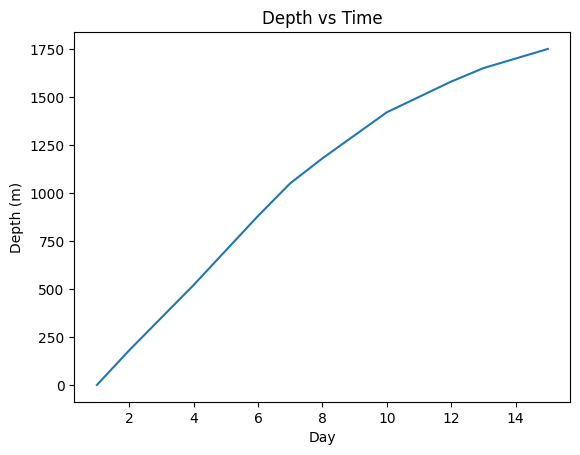

In [ ]:
plt.figure()
plt.plot(df["Day"], df["Depth_m"])
plt.xlabel("Day")
plt.ylabel("Depth (m)")
plt.title("Depth vs Time")
plt.show()

In [ ]:
df["Daily_Depth_Change"] = df["Depth_m"].diff()
df["ROP_m_per_day"] = df["Daily_Depth_Change"]

df.head()

,Day,Depth_m,Daily_Cost_USD,NPT_hours,Daily_Depth_Change,ROP_m_per_day
0,1,0,45000,0,NaN,NaN
1,2,180,46000,2,180.0,180.0
2,3,350,47000,0,170.0,170.0
3,4,520,48000,1,170.0,170.0
4,5,700,50000,3,180.0,180.0


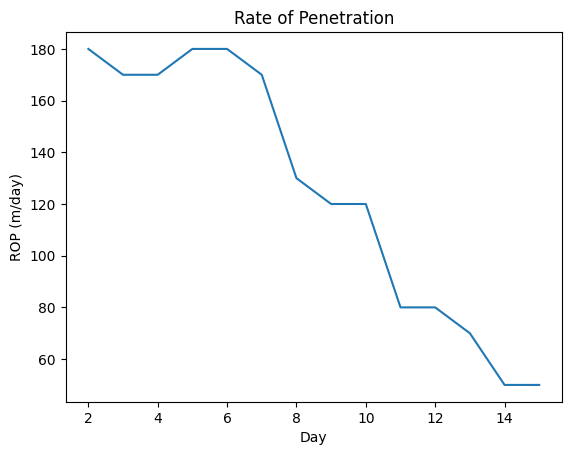

In [ ]:
plt.figure()
plt.plot(df["Day"], df["ROP_m_per_day"])
plt.xlabel("Day")
plt.ylabel("ROP (m/day)")
plt.title("Rate of Penetration")
plt.show()

In [ ]:
df["ROP_Flag"] = np.where(df["ROP_m_per_day"] < 120, "Low ROP", "Normal")
df[["Day", "ROP_m_per_day", "ROP_Flag"]]

,Day,ROP_m_per_day,ROP_Flag
0,1,NaN,Normal
1,2,180.0,Normal
2,3,170.0,Normal
3,4,170.0,Normal
4,5,180.0,Normal
5,6,180.0,Normal
6,7,170.0,Normal
7,8,130.0,Normal
8,9,120.0,Normal
9,10,120.0,Normal


In [ ]:
total_npt = df["NPT_hours"].sum()
total_npt

np.int64(18)

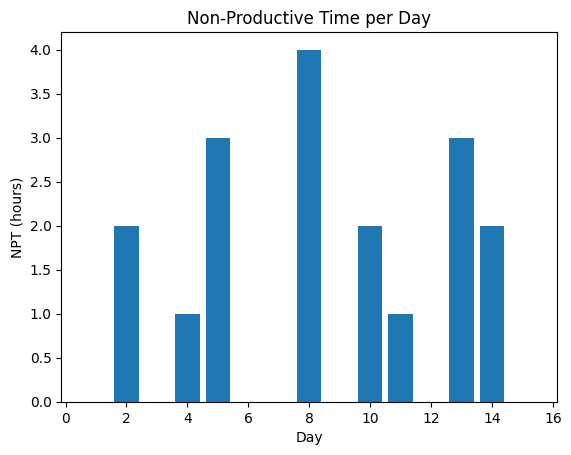

In [ ]:
plt.figure()
plt.bar(df["Day"], df["NPT_hours"])
plt.xlabel("Day")
plt.ylabel("NPT (hours)")
plt.title("Non-Productive Time per Day")
plt.show()

In [ ]:
total_cost = df["Daily_Cost_USD"].sum()
total_cost

np.int64(836000)

In [ ]:
final_depth = df["Depth_m"].iloc[-1]
cost_per_meter = total_cost / final_depth
cost_per_meter

np.float64(477.7142857142857)

In [ ]:
correlation = df["NPT_hours"].corr(df["ROP_m_per_day"])
correlation

np.float64(-0.03285106006801568)